# Übung Simulation von Energiesystemen 
## PyPSA 01

### Aufgabe 1: Installieren und Importieren von PyPSA

Der Jupyter Hub Server hat eine conda Umgebung, in welcher viele Python Bibliotheken schon vorinstalliert sind. <br> Schaffen Sie sich zunächst mit dem Befehl _conda list_ einen Überblick über die Bibliotheken und prüfen Sie ob PyPSA schon bei Ihnen installiert ist.

Da PyPSA bei Ihnen installiert ist, können Sie die Bibliothek mit dem Befehl _import pypsa_ einbinden. Tun Sie dies.

In [1]:
import pypsa

C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


Erzeugen Sie nun eine Variable network_1, welche ein Netzwerkobjekt enthält. Dies können Sie über die pypsa Bibliothek und die Funktion _pypsa.Network()_ tun. <br> Nutzen Sie anschließend die Methode set_snapshots und setzen Sie diese auf [0,1,2,3]

In [2]:
network_1 = pypsa.Network()
network_1.set_snapshots([0,1,2,3])

In [3]:
network_1

Empty PyPSA Network
Components: none
Snapshots: 4

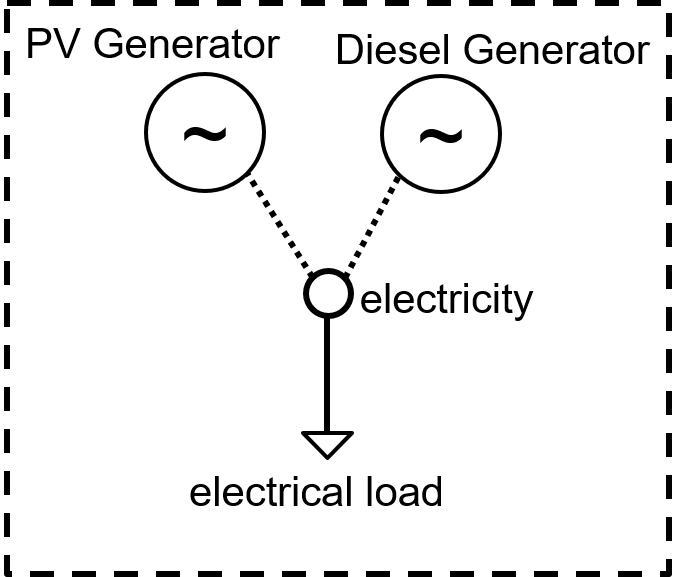

Fügen Sie ihrem Netzwerk mit der methode add() nun die folgenden Komponenten hinzu:
* Knoten mit dem Namen 'electricity'
* Last an diesem Knoten mit dem namen 'elektrical_load' und dieser Lastzeitreihe in MW: [4, 5, 14, 12] 
* Generator an diesem Knoten mit der Nennleistung 10 MW, dem Namen 'PV Generator' und marginalen Kosten von 0 €/MWh. <br> 
Der Generator kann im ersten Zeitpunkt keine Leistung im zweiten und dritten Zeitpunkt maximal 60% der Nennleistung und im vierten Zeitschritt keine Leistung bereitstellen.
* Generator an diesem Knoten mit der Nennleistung 20 MW, dem Namen 'Diesel Generator' und marginalen Kosten von 15 €/MWh.

In [4]:
network_1.add('Bus', name = 'electricity')


In [5]:
network_1.add('Load', name = 'electrical_load', bus = 'electricity', p_set = [4, 5, 14, 12])

In [6]:
network_1.add('Generator', name = 'Diesel', bus = 'electricity', p_nom = 20, marginal_cost = 15, overwrite = True)

In [7]:
network_1.add('Generator', name = 'PV', bus = 'electricity', p_nom = 10, p_max_pu = [0, 0.6, 0.6, 0])

In [8]:
network_1.generators

attribute,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
Generator,,,,,,,,,,,,,,,,,,,,,
Diesel,electricity,PQ,,20.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0
PV,electricity,PQ,,10.0,0.0,False,0.0,inf,0.0,1.0,...,0,0,1,0,NaN,NaN,1.0,1.0,1.0,0.0


Optimieren Sie das Energiemodell mit _network_1.optimize(solver_name = 'gurobi')_ <br> Lassen Sie sich anschließend die Ergbnisse mit den folgenden Befehlen veranschaulichen:
* network_1.loads_t.p.plot()
* network_1.generators_t.p.plot(kind = 'bar')
* network_1.buses_t.marginal_price.plot()

In [9]:
network_1.optimize(solver_name = 'gurobi')

Index(['electricity'], dtype='object', name='Bus')
Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2694931


INFO:gurobipy:Set parameter LicenseID to value 2694931


...

Solved in 0 iterations and 0.01 seconds (0.00 work units)


INFO:gurobipy:Solved in 0 iterations and 0.01 seconds (0.00 work units)


Optimal objective  3.600000000e+02


INFO:gurobipy:Optimal objective  3.600000000e+02
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 8 primals, 20 duals
Objective: 3.60e+02
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper were not assigned to the network.


('ok', 'optimal')

<Axes: xlabel='snapshot'>

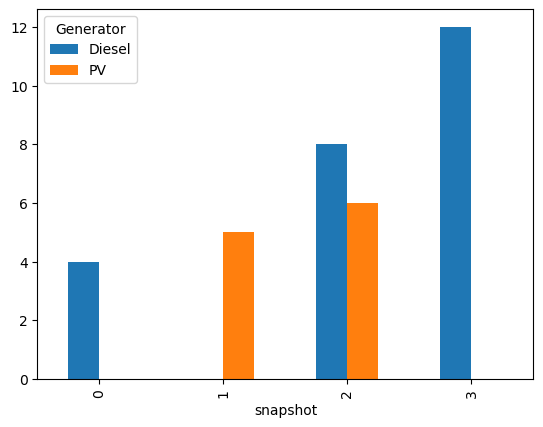

In [10]:
network_1.generators_t.p.plot(kind = 'bar')

<Axes: xlabel='snapshot'>

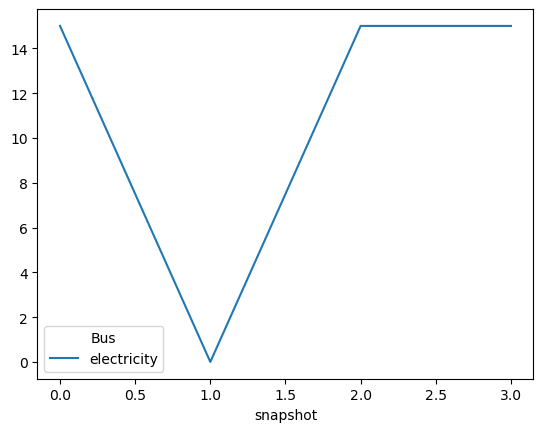

In [11]:
network_1.buses_t.marginal_price.plot()